# Task 2: 单比特退相干

这个 notebook 演示单比特在不同噪声环境下的演化。我们利用 `musiq` 的参数扫描（Parameter Scan）功能来分析 $T_1$ 弛豫、$T_2$ 退相干以及 Ramsey/Spin-echo 实验中的延迟扫描。

In [1]:
# -*- coding: utf-8 -*-
from __future__ import annotations

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from musiq.workflow import create_model, load_config
from musiq.schemas.utils import ParameterSweepConfig, ParameterList


MODEL_DIR = Path(".")
FIG_DIR = MODEL_DIR / "figures"
FIG_DIR.mkdir(exist_ok=True)


## 1. 运行噪声场景

我们将不同的噪声参数和门角度定义在 `ParameterSweepConfig` 中。`model.run_all()` 将自动执行所有参数组合，从而覆盖我们关注的几个典型退相干场景。

In [2]:
import copy

# 1. 准备不同参数的设备配置
device_default = load_config(MODEL_DIR / "device.yaml", "device")
device_1 = copy.deepcopy(device_default)
device_1.device['components'][0]['noise'] = {"T1_s": 32.0e-6, "T2_s": 16.0e-6}
device_2 = copy.deepcopy(device_default)
device_2.device['components'][0]['noise'] = {"T1_s": 32.0e-6, "T2_s": 9.0e-6}

# 3. 创建模型
model = create_model(
    circuits = {
        "x": MODEL_DIR / "circuit_x.yaml",
        "h": MODEL_DIR / "circuit_h.yaml"
    },
    devices = {
        "default" :device_default,
        "Dephasing_off": device_1,
        "Dephasing_on": device_2
    },
    pulses = MODEL_DIR / "pulse.yaml",
    solvers = MODEL_DIR / "solver.yaml",
    analysers = MODEL_DIR / "analyser.yaml",
    profiles = {
        "Relaxation": {
            "circuit_id": "x",
            "device_id": "default",
        },
        "Dephasing_off": {
            "circuit_id": "h",
            "device_id": "Dephasing_off",
        },
        "Dephasing_on": {
            "circuit_id": "h",
            "device_id": "Dephasing_on",
        }
    }
)

# 4. 执行指定 Profile
t1_profile = model.profile("Relaxation")
t2_profile = model.profile("Dephasing_off")
t2_tphi_profile = model.profile("Dephasing_on")

t1_run_id = t1_profile.run_solver()[0]
t1_profile.run_analysis(run_ids=[t1_run_id])
t1_analysis = model.find_analysis_for_run(t1_run_id)
t1_run = model.runs["solver_0"][t1_run_id]

t2_run_id = t2_profile.run_solver()[0]
t2_profile.run_analysis(run_ids=[t2_run_id])
t2_analysis = model.find_analysis_for_run(t2_run_id)
t2_run = model.runs["solver_0"][t2_run_id]

t2_tphi_run_id = t2_tphi_profile.run_solver()[0]
t2_tphi_profile.run_analysis(run_ids=[t2_tphi_run_id])
t2_tphi_analysis = model.find_analysis_for_run(t2_tphi_run_id)
t2_tphi_run = model.runs["solver_0"][t2_tphi_run_id]

print("Completed solver groups:", sorted(model.runs.keys()))
print("Completed run ids:", sorted(model.runs["solver_0"].keys()))
print("Completed analyses:", sorted(model.analyses.keys()))


Completed solver groups: ['solver_0']
Completed run ids: ['single_qubit_decoherence', 'single_qubit_decoherence_0', 'single_qubit_decoherence_1']
Completed analyses: ['case_0', 'case_1', 'case_2']


## 2. 结果绘图

由于使用了参数扫描，我们通过筛选 `model.runs` 中参数匹配的结果来提取特定场景。

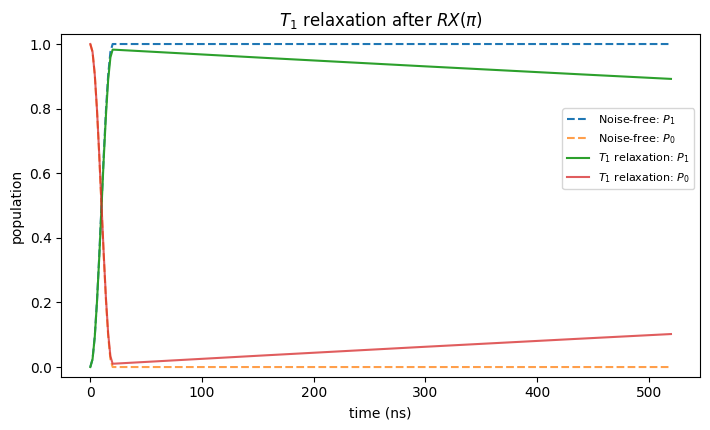

In [3]:

fig, ax = plt.subplots(figsize=(7.2, 4.4))

T1_metrics = t1_analysis.output.metrics["population"]
t1 = np.asarray(T1_metrics.times, dtype=float) * 1e9
p0 = np.asarray(T1_metrics.values["0"], dtype=float)
p1 = np.asarray(T1_metrics.values["1"], dtype=float)

pulse_end_ns = float(t1_run.artifacts.pulse_ir.t_end_ns)

theta_ideal = np.minimum(t1 / pulse_end_ns, 1.0) * np.pi
ax.plot(t1, np.sin(theta_ideal / 2) ** 2, linestyle="--", label=r"Noise-free: $P_1$")
ax.plot(t1, np.cos(theta_ideal / 2) ** 2, linestyle="--", alpha=0.75, label=r"Noise-free: $P_0$")

ax.plot(t1, p1, label=r"$T_1$ relaxation: $P_1$")
ax.plot(t1, p0, alpha=0.75, label=r"$T_1$ relaxation: $P_0$")

ax.set_title(r"$T_1$ relaxation after $RX(π)$")
ax.set_xlabel("time (ns)")
ax.set_ylabel("population")
ax.set_ylim(-0.03, 1.03)
ax.legend(fontsize=8, ncol=1, bbox_to_anchor=(1.0, 0.8))
fig.tight_layout()
fig.savefig(FIG_DIR / "t1_relaxation.png", dpi=600)
plt.show()


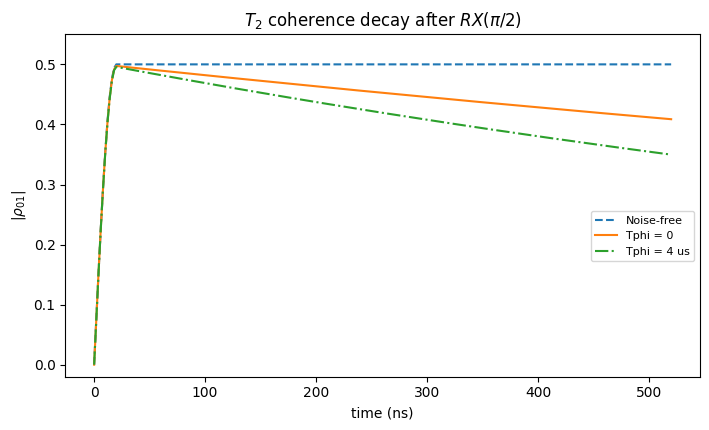

In [4]:
fig, ax = plt.subplots(figsize=(7.2, 4.4))

T2_metrics_1 = t2_analysis.output.metrics["coherence_01"]
T2_metrics_2 = t2_tphi_analysis.output.metrics["coherence_01"]
t2 = np.asarray(T2_metrics_1.times, dtype=float) * 1e9
c1 = np.asarray(T2_metrics_1.values, dtype=float)
c2 = np.asarray(T2_metrics_2.values, dtype=float)

pulse_end_ns = float(t2_run.artifacts.pulse_ir.t_end_ns)

theta_ideal = np.minimum(t2 / pulse_end_ns, 1.0) * np.pi / 2
ax.plot(t2, 0.5 * np.abs(np.sin(theta_ideal)), linestyle="--", label=r"Noise-free")

ax.plot(t2, c1, linestyle="-", label="Tphi = 0")
ax.plot(t2, c2, linestyle="-.", label="Tphi = 4 us")

ax.set_title(r"$T_2$ coherence decay after $RX(π/2)$")
ax.set_xlabel("time (ns)")
ax.set_ylabel(r"$|\rho_{01}|$")
ax.set_ylim(-0.02, 0.55)
ax.legend(fontsize=8, bbox_to_anchor=(1., 0.5))
fig.tight_layout()
fig.savefig(FIG_DIR / "T2_coherence_decay.png", dpi=600)
plt.show()


## 3. HEOM 性能分析

在使用 native 1/f 噪声（HEOM 模拟）时，可能会发现模拟速度较慢。这是因为 HEOM 将密度矩阵扩展到了一个辅助密度算符（ADO）层级结构中。

**性能瓶颈分析：**
1. **状态空间爆炸**：ADO 的数量由 $\binom{N+M}{M}$ 决定，其中 $N$ 是 Bath 指数项数 (`nterms`)，$M$ 是层级深度 (`max_depth`)。默认 $N=6, M=3$ 时有 84 个 ADO。
2. **计算复杂度**：每个 ADO 都是一个 $d \times d$ 的矩阵（$d$ 为希尔伯特空间维度），求解过程涉及大规模 ODE 积分。

**优化建议：**
- 降低 `backend_options.heom.max_depth`（如设为 2）。
- 减少 `backend_options.heom.nterms`（如设为 4）。
- 增加时间步长 $\Delta t$ 以减少积分点数。

## 4. Ramsey 与 Spin Echo 的参数扫描

这里我们将延迟 `idle_duration_ns` 定义为参数，利用 `ParameterSweepConfig` 一次性跑完所有延迟点。

In [7]:
delay_times_ns = np.linspace(100, 20e3, 31)
t_pi_ns = 15.0

model_ramsey = create_model(
    circuits = MODEL_DIR / "circuit_ramsey.yaml",
    solvers = MODEL_DIR / "solver_1overf.yaml",
    analysers = MODEL_DIR / "analyser_sweep.yaml",
    devices = MODEL_DIR / "device_1overf.yaml",
    pulses = MODEL_DIR / "pulse_1overf.yaml",
    parameter_sweep = {"pulse:gates.id.duration_ns": delay_times_ns.tolist()}
)
model_echo = create_model(
    circuits = MODEL_DIR / "circuit_echo.yaml",
    solvers = MODEL_DIR / "solver_1overf.yaml",
    analysers = MODEL_DIR / "analyser_sweep.yaml",
    devices = MODEL_DIR / "device_1overf.yaml",
    pulses = MODEL_DIR / "pulse_1overf.yaml",
    parameter_sweep = {"pulse:gates.id.duration_ns": ((delay_times_ns-t_pi_ns)/2).tolist()}
)

model_ramsey.run_all()
model_echo.run_all()


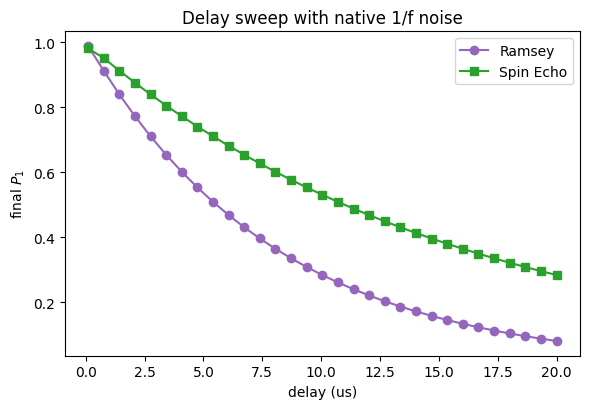

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(delay_times_ns * 1e-3, model_ramsey.analyses['sweep_0'].output.metrics["final_P1"].values, "o-", color="tab:purple", label="Ramsey")
ax.plot(delay_times_ns * 1e-3, model_echo.analyses['sweep_0'].output.metrics["final_P1"].values, "s-", color="tab:green", label="Spin Echo")
ax.set_title("Delay sweep with native 1/f noise")
ax.set_xlabel("delay (us)")
ax.set_ylabel("final $P_1$")
ax.set_ylim(0.47, 1.03)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "ramsey_echo_1f_delay_scan.png", dpi=600)
plt.show()


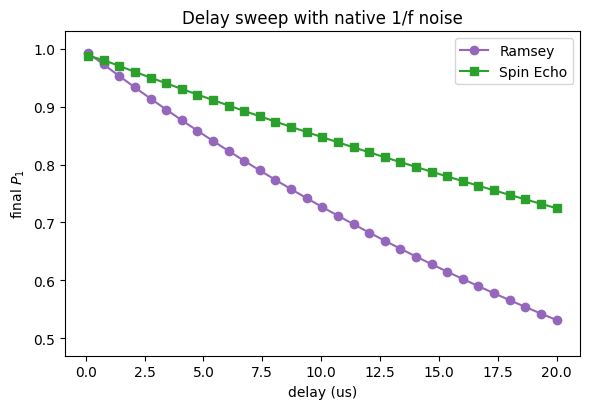

In [8]:
fig, ax = plt.subplots(figsize=(6, 4.2))
ax.plot(delay_times_ns * 1e-3, model_ramsey.analyses['sweep_0'].output.metrics["final_P1"].values, "o-", color="tab:purple", label="Ramsey")
ax.plot(delay_times_ns * 1e-3, model_echo.analyses['sweep_0'].output.metrics["final_P1"].values, "s-", color="tab:green", label="Spin Echo")
ax.set_title("Delay sweep with native 1/f noise")
ax.set_xlabel("delay (us)")
ax.set_ylabel("final $P_1$")
ax.set_ylim(0.47, 1.03)
ax.legend()
fig.tight_layout()
fig.savefig(FIG_DIR / "ramsey_echo_1f_delay_scan.png", dpi=600)
plt.show()

## 5. 结论

通过对比不同噪声场景，我们观察到了 $T_1$ 弛豫导致的 population 衰减和 $T_2$ 导致的 coherence 丢失。利用 `ParameterSweepConfig` 实现了高度结构化的参数化模拟。